# Inital data read

In [1]:
import pandas as pd
import numpy as np

# ============================================================
# LOAD DATASET
# ============================================================

file_path = r"C:\Users\DELL\OneDrive\Desktop\DAIICT\SEM1_DS605\Lab504\AB_NYC_2019.csv"

df = pd.read_csv(file_path)

# ============================================================
# INITIAL DATASET DIAGNOSTICS
# ============================================================

print("=" * 70)
print("AIRBNB NYC 2019 DATASET — INITIAL DIAGNOSTICS")
print("=" * 70)

# Shape
print("\n1. DATASET SHAPE")
print("-" * 70)
print(f"Number of rows    : {df.shape[0]:,}")
print(f"Number of columns : {df.shape[1]}")

# Column names and data types
print("\n2. COLUMNS AND DATA TYPES")
print("-" * 70)

column_info = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Non-Null Count": df.notna().sum(),
    "Missing Count": df.isna().sum(),
    "Missing (%)": (df.isna().mean() * 100).round(2),
    "Unique Values": df.nunique()
})

display(column_info)

# First rows
print("\n3. FIRST 5 ROWS")
print("-" * 70)
display(df.head())

# Numerical summary
print("\n4. NUMERICAL FEATURES — DESCRIPTIVE STATISTICS")
print("-" * 70)
display(df.describe().T)

# Categorical/object summary
print("\n6. CATEGORICAL / TEXT FEATURES — DESCRIPTIVE STATISTICS")
print("-" * 70)
display(df.describe(include="object").T)

# Duplicate rows
print("\n7. DUPLICATE ROWS")
print("-" * 70)
print(f"Number of completely duplicated rows: {df.duplicated().sum():,}")

AIRBNB NYC 2019 DATASET — INITIAL DIAGNOSTICS

1. DATASET SHAPE
----------------------------------------------------------------------
Number of rows    : 48,895
Number of columns : 16

2. COLUMNS AND DATA TYPES
----------------------------------------------------------------------


,Column,Data Type,Non-Null Count,Missing Count,Missing (%),Unique Values
id,id,int64,48895,0,0.00,48895
name,name,object,48879,16,0.03,47905
host_id,host_id,int64,48895,0,0.00,37457
host_name,host_name,object,48874,21,0.04,11452
neighbourhood_group,neighbourhood_group,object,48895,0,0.00,5
neighbourhood,neighbourhood,object,48895,0,0.00,221
latitude,latitude,float64,48895,0,0.00,19048
longitude,longitude,float64,48895,0,0.00,14718
room_type,room_type,object,48895,0,0.00,3
price,price,int64,48895,0,0.00,674



3. FIRST 5 ROWS
----------------------------------------------------------------------


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0



4. NUMERICAL FEATURES — DESCRIPTIVE STATISTICS
----------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
id,48895.0,1.901714e+07,1.098311e+07,2539.00000,9.471945e+06,1.967728e+07,2.915218e+07,3.648724e+07
host_id,48895.0,6.762001e+07,7.861097e+07,2438.00000,7.822033e+06,3.079382e+07,1.074344e+08,2.743213e+08
latitude,48895.0,4.072895e+01,5.453008e-02,40.49979,4.069010e+01,4.072307e+01,4.076311e+01,4.091306e+01
longitude,48895.0,-7.395217e+01,4.615674e-02,-74.24442,-7.398307e+01,-7.395568e+01,-7.393627e+01,-7.371299e+01
price,48895.0,1.527207e+02,2.401542e+02,0.00000,6.900000e+01,1.060000e+02,1.750000e+02,1.000000e+04
minimum_nights,48895.0,7.029962e+00,2.051055e+01,1.00000,1.000000e+00,3.000000e+00,5.000000e+00,1.250000e+03
number_of_reviews,48895.0,2.327447e+01,4.455058e+01,0.00000,1.000000e+00,5.000000e+00,2.400000e+01,6.290000e+02
reviews_per_month,38843.0,1.373221e+00,1.680442e+00,0.01000,1.900000e-01,7.200000e-01,2.020000e+00,5.850000e+01
calculated_host_listings_count,48895.0,7.143982e+00,3.295252e+01,1.00000,1.000000e+00,1.000000e+00,2.000000e+00,3.270000e+02
availability_365,48895.0,1.127813e+02,1.316223e+02,0.00000,0.000000e+00,4.500000e+01,2.270000e+02,3.650000e+02



6. CATEGORICAL / TEXT FEATURES — DESCRIPTIVE STATISTICS
----------------------------------------------------------------------


,count,unique,top,freq
name,48879,47905,Hillside Hotel,18
host_name,48874,11452,Michael,417
neighbourhood_group,48895,5,Manhattan,21661
neighbourhood,48895,221,Williamsburg,3920
room_type,48895,3,Entire home/apt,25409
last_review,38843,1764,2019-06-23,1413



7. DUPLICATE ROWS
----------------------------------------------------------------------
Number of completely duplicated rows: 0


We analyze now using the training set only, because the test set must remain completely unseen during model development.

In [2]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# ---------------------------------------------------------
# Load the original dataset
# ---------------------------------------------------------

data_path = r"C:\Users\DELL\OneDrive\Desktop\DAIICT\SEM1_DS605\Lab504\AB_NYC_2019.csv"

df = pd.read_csv(data_path)

print("Original dataset shape:", df.shape)

# ---------------------------------------------------------
# Train-test split
# ---------------------------------------------------------

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42
)

print("Training set shape:", train_df.shape)
print("Test set shape    :", test_df.shape)

# ---------------------------------------------------------
# Save the split datasets
# ---------------------------------------------------------

data_folder = r"C:\Users\DELL\OneDrive\Desktop\DAIICT\SEM1_DS605\Lab504\data"

os.makedirs(data_folder, exist_ok=True)

train_path = os.path.join(data_folder, "train.csv")
test_path = os.path.join(data_folder, "test.csv")

train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path, index=False)

print("\nSaved:")
print("Train:", train_path)
print("Test :", test_path)

Original dataset shape: (48895, 16)
Training set shape: (39116, 16)
Test set shape    : (9779, 16)

Saved:
Train: C:\Users\DELL\OneDrive\Desktop\DAIICT\SEM1_DS605\Lab504\data\train.csv
Test : C:\Users\DELL\OneDrive\Desktop\DAIICT\SEM1_DS605\Lab504\data\test.csv


### Spatial Feature Engineering — Initial Investigation

We investigate whether geographic concentration contains information beyond `neighbourhood`.
For each neighbourhood, local listing density is estimated from nearby listings, and the densest 10%
of listings are used to define a neighbourhood's spatial centre. At the city level, we estimate local
price using nearby listings and use the top 1% of locations with the highest local prices to define
a high-price centre. Later, distances from these centres can be tested as engineered predictors.
The 10% and 1% thresholds are exploratory choices and will be validated rather than assumed optimal.

1. NEIGHBOURHOOD GROUP SUMMARY


,listings,mean_price,median_price,std_price,min_price,max_price,q1_price,q3_price,IQR,listing_percentage
neighbourhood_group,,,,,,,,,,
Manhattan,17380,198.608688,150.0,308.082056,0,10000,95.0,220.0,125.0,44.431946
Brooklyn,16096,124.630467,90.0,174.996973,0,7500,60.0,150.0,90.0,41.149402
Queens,4482,99.323963,75.0,176.504559,10,10000,50.0,110.0,60.0,11.458227
Staten Island,294,116.037415,75.0,307.606929,13,5000,50.0,105.0,55.0,0.751611
Bronx,864,89.109954,65.0,115.115100,0,2500,45.0,100.0,55.0,2.208815



2. NEIGHBOURHOOD SUMMARY


,neighbourhood_group,neighbourhood,listings,mean_price,median_price,std_price,min_price,max_price,q1_price,q3_price,IQR,listing_percentage
0,Staten Island,Fort Wadsworth,1,800.000000,800.0,NaN,800,800,800.0,800.00,0.00,0.002556
1,Brooklyn,Sea Gate,4,749.000000,707.0,754.907500,97,1485,98.5,1357.50,1259.00,0.010226
2,Manhattan,Tribeca,144,495.729167,281.0,933.948077,60,8500,196.5,442.50,246.00,0.368136
3,Staten Island,Willowbrook,1,249.000000,249.0,NaN,249,249,249.0,249.00,0.00,0.002556
4,Queens,Neponsit,2,237.000000,237.0,52.325902,200,274,218.5,255.50,37.00,0.005113
...,...,...,...,...,...,...,...,...,...,...,...,...
215,Queens,Corona,49,61.673469,40.0,54.384583,23,359,36.0,69.00,33.00,0.125268
216,Staten Island,Westerleigh,1,40.000000,40.0,NaN,40,40,40.0,40.00,0.00,0.002556
217,Bronx,Belmont,17,66.411765,35.0,58.541715,24,247,29.0,95.00,66.00,0.043460
218,Staten Island,Concord,22,52.636364,34.0,43.556800,29,200,32.0,38.75,6.75,0.056243



3. MEDIAN PRICE HEATMAP


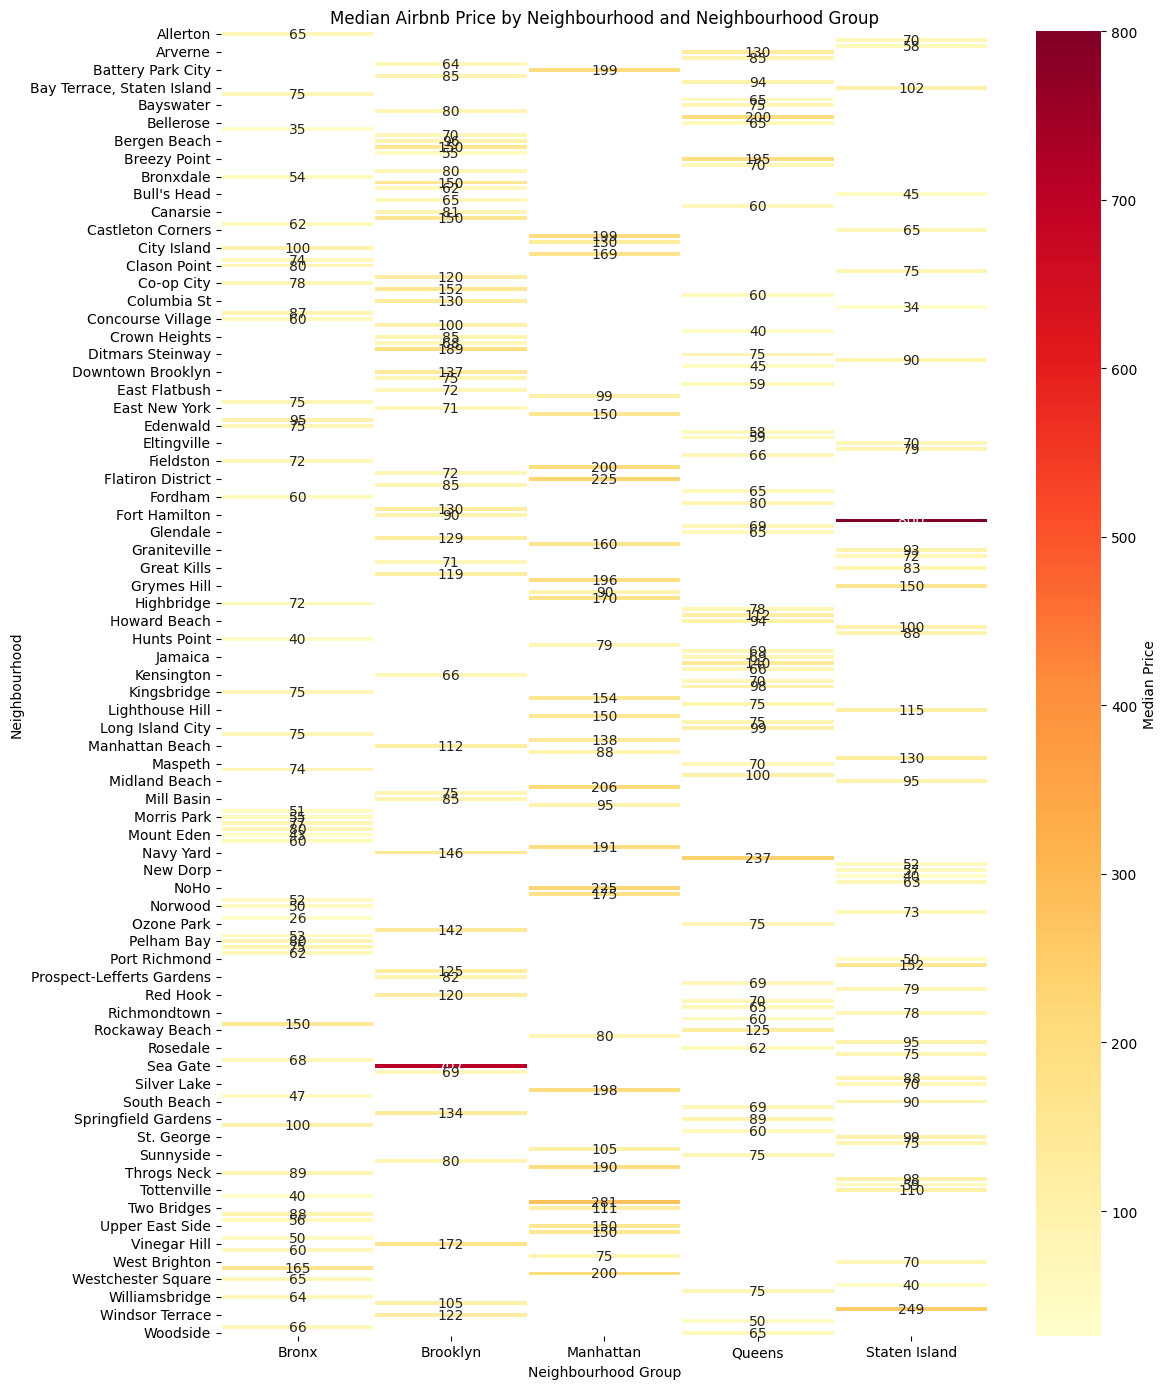


4. NYC LISTING DENSITY


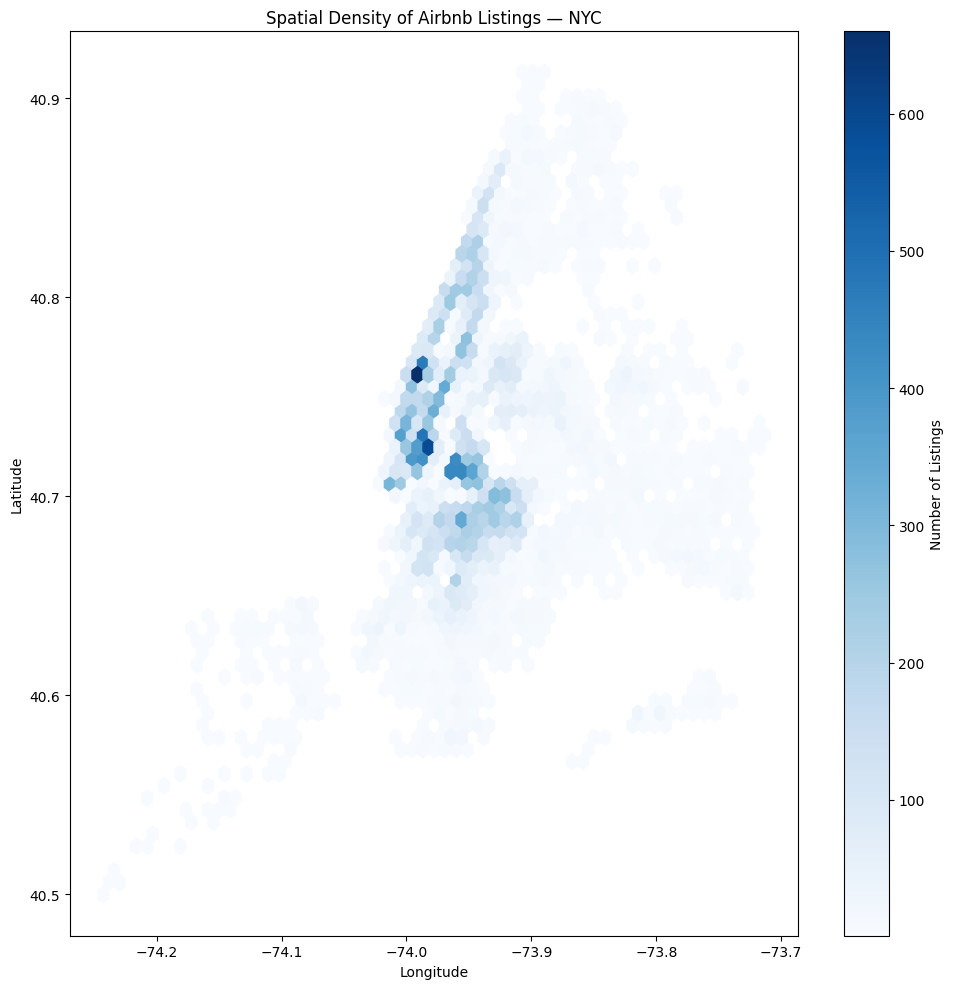

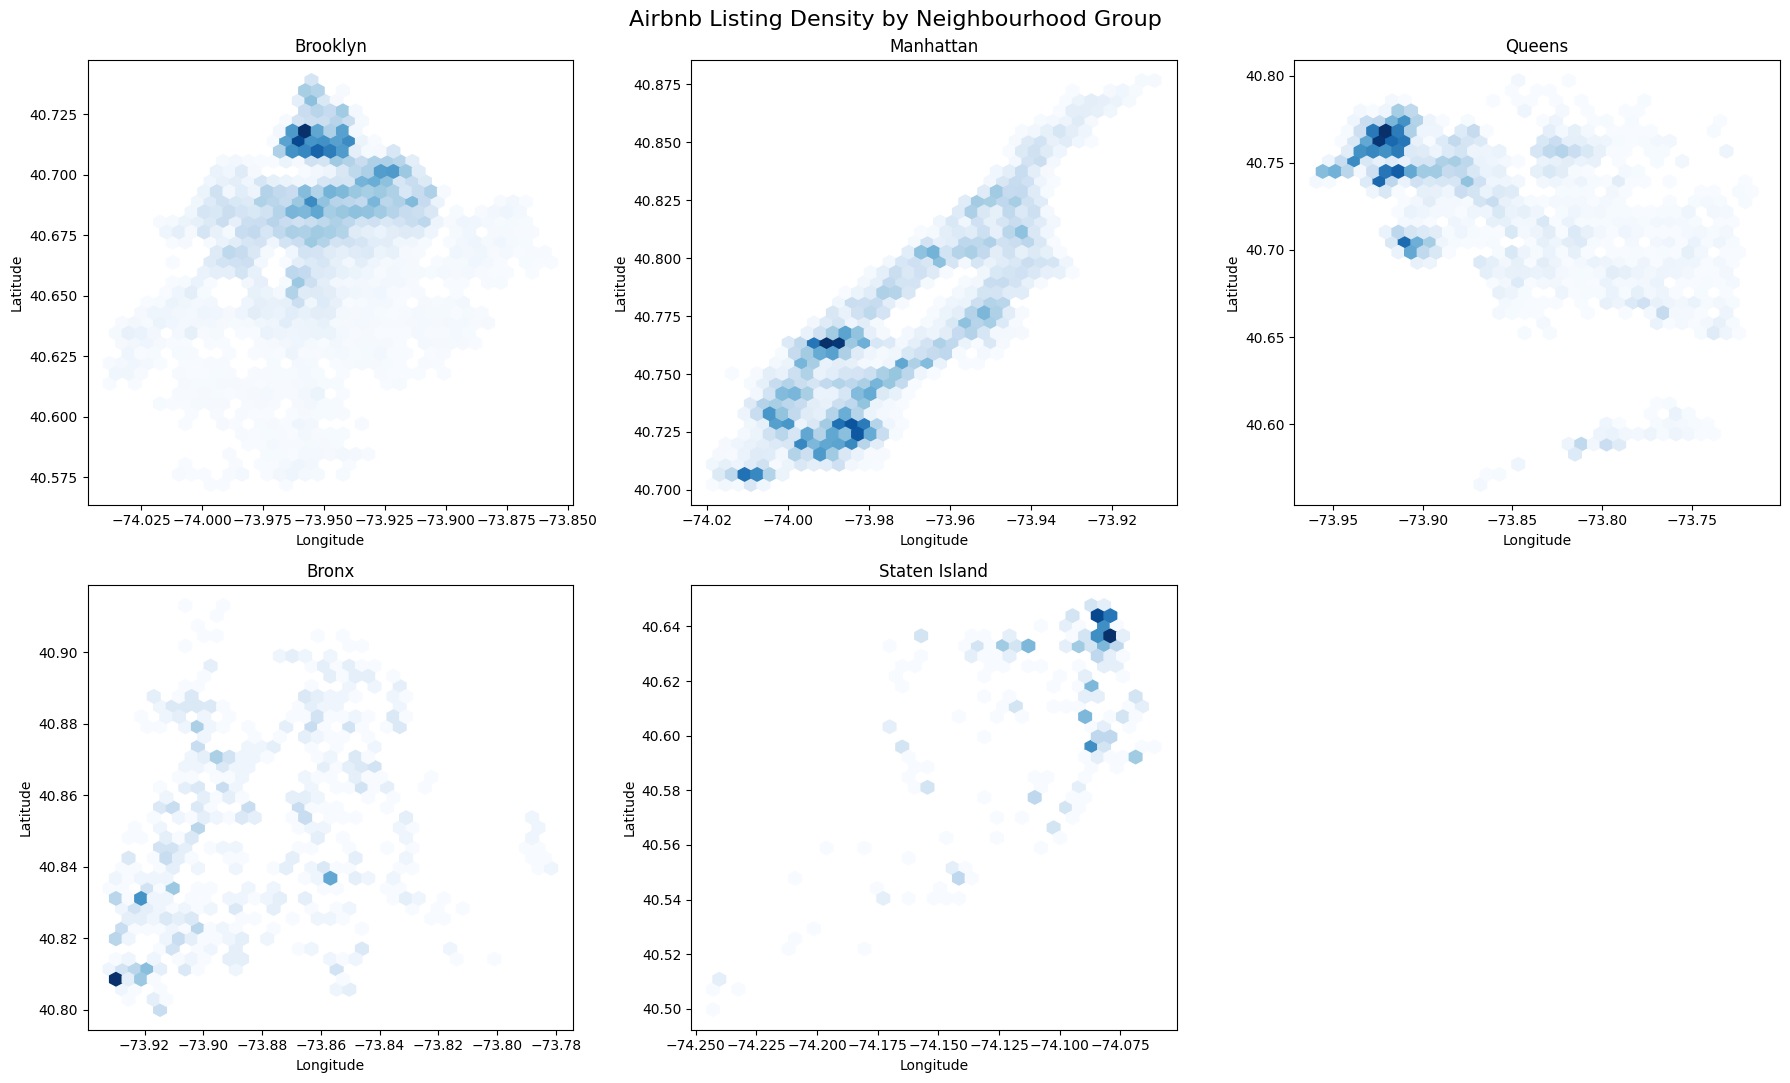


5. CALCULATING LOCAL SPATIAL DENSITY
Local density calculated.
count    39116.000000
mean      1179.501155
std        617.827488
min         15.623035
25%        754.383788
50%       1138.774588
75%       1538.880741
max       4811.732645
Name: local_density, dtype: float64

6. NEIGHBOURHOOD DENSE-CORE CENTRES


,neighbourhood,n_listings,dense_core_listings,centre_latitude,centre_longitude,method
214,Williamsburg,3150,315,40.713164,-73.956454,dense_core
13,Bedford-Stuyvesant,2983,299,40.688819,-73.949931,dense_core
94,Harlem,2136,214,40.815537,-73.949859,dense_core
28,Bushwick,1951,196,40.699862,-73.924045,dense_core
202,Upper West Side,1592,160,40.798020,-73.965187,dense_core
...,...,...,...,...,...,...
114,Lighthouse Hill,1,1,40.576410,-74.129310,neighbourhood_mean
100,Howland Hook,1,1,40.632450,-74.170650,neighbourhood_mean
82,Fort Wadsworth,1,1,40.595460,-74.060920,neighbourhood_mean
165,Richmondtown,1,1,40.570930,-74.124290,neighbourhood_mean



7. CITY-WIDE LOCAL PRICE ANALYSIS
Local mean price calculated.


,price,local_mean_price
count,39116.000000,39116.000000
mean,153.751585,153.068500
std,247.037941,86.384648
min,0.000000,35.050000
25%,69.000000,94.400000
50%,107.000000,132.500000
75%,175.250000,185.550000
max,10000.000000,1277.000000



Local-price threshold for top 1%: $477.49
Listings representing top 1%: 392

NYC high-price centre:
Latitude  : 40.745660
Longitude : -73.979714


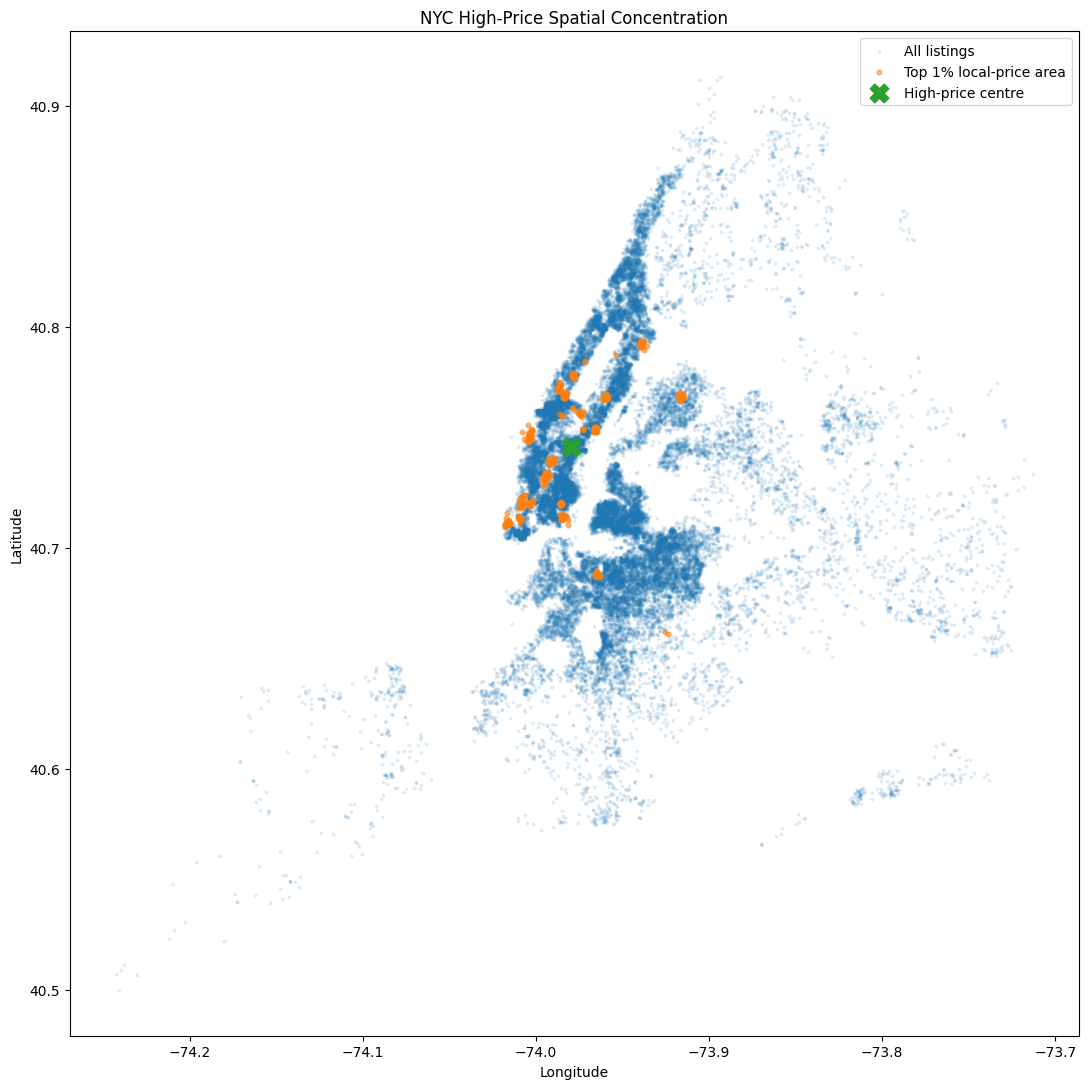


8. ENGINEERED SPATIAL FEATURES — INITIAL RELATIONSHIP WITH PRICE


price                           1.000000
local_mean_price                0.227442
local_density                   0.094614
dist_to_neighbourhood_center   -0.042281
dist_to_high_price_center      -0.163955
Name: price, dtype: float64

In [3]:
# ============================================================
# SPATIAL ANALYSIS AND FEATURE ENGINEERING INVESTIGATION
# ============================================================

from sklearn.neighbors import NearestNeighbors
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ------------------------------------------------------------
# PARAMETERS — exploratory choices
# ------------------------------------------------------------

NEIGHBOURHOOD_DENSITY_PERCENTILE = 90   # top 10% densest listings
CITY_PRICE_PERCENTILE = 99              # top 1% highest local-price areas
K_NEIGHBOURS = 20                       # local neighbourhood size


# ------------------------------------------------------------
# 1. CATEGORICAL SUMMARY
# ------------------------------------------------------------

print("=" * 80)
print("1. NEIGHBOURHOOD GROUP SUMMARY")
print("=" * 80)

group_summary = (
    train_df.groupby("neighbourhood_group")
    .agg(
        listings=("id", "count"),
        mean_price=("price", "mean"),
        median_price=("price", "median"),
        std_price=("price", "std"),
        min_price=("price", "min"),
        max_price=("price", "max"),
        q1_price=("price", lambda x: x.quantile(0.25)),
        q3_price=("price", lambda x: x.quantile(0.75))
    )
)

group_summary["IQR"] = (
    group_summary["q3_price"] -
    group_summary["q1_price"]
)

group_summary["listing_percentage"] = (
    group_summary["listings"] /
    len(train_df) * 100
)

display(
    group_summary.sort_values(
        "median_price",
        ascending=False
    )
)


# ------------------------------------------------------------
# 2. NEIGHBOURHOOD SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("2. NEIGHBOURHOOD SUMMARY")
print("=" * 80)

neighbourhood_summary = (
    train_df
    .groupby(
        ["neighbourhood_group", "neighbourhood"]
    )
    .agg(
        listings=("id", "count"),
        mean_price=("price", "mean"),
        median_price=("price", "median"),
        std_price=("price", "std"),
        min_price=("price", "min"),
        max_price=("price", "max"),
        q1_price=("price", lambda x: x.quantile(0.25)),
        q3_price=("price", lambda x: x.quantile(0.75))
    )
    .reset_index()
)

neighbourhood_summary["IQR"] = (
    neighbourhood_summary["q3_price"] -
    neighbourhood_summary["q1_price"]
)

neighbourhood_summary["listing_percentage"] = (
    neighbourhood_summary["listings"] /
    len(train_df) * 100
)

display(
    neighbourhood_summary
    .sort_values(
        "median_price",
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 3. PRICE HEATMAP BY NEIGHBOURHOOD
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("3. MEDIAN PRICE HEATMAP")
print("=" * 80)

price_heatmap = (
    train_df.pivot_table(
        index="neighbourhood",
        columns="neighbourhood_group",
        values="price",
        aggfunc="median"
    )
)

plt.figure(figsize=(12, 14))

sns.heatmap(
    price_heatmap,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.3,
    cbar_kws={"label": "Median Price"}
)

plt.title(
    "Median Airbnb Price by Neighbourhood and Neighbourhood Group"
)
plt.xlabel("Neighbourhood Group")
plt.ylabel("Neighbourhood")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. LISTING DENSITY HEATMAP — WHOLE NYC
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("4. NYC LISTING DENSITY")
print("=" * 80)

plt.figure(figsize=(10, 10))

plt.hexbin(
    train_df["longitude"],
    train_df["latitude"],
    gridsize=60,
    mincnt=1,
    cmap="Blues"
)

plt.colorbar(label="Number of Listings")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Density of Airbnb Listings — NYC")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. LISTING DENSITY BY NEIGHBOURHOOD GROUP
# ------------------------------------------------------------

groups = (
    train_df["neighbourhood_group"]
    .dropna()
    .unique()
)

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(18, 11)
)

axes = axes.flatten()

for ax, group in zip(axes, groups):

    subset = train_df[
        train_df["neighbourhood_group"] == group
    ]

    ax.hexbin(
        subset["longitude"],
        subset["latitude"],
        gridsize=35,
        mincnt=1,
        cmap="Blues"
    )

    ax.set_title(group)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

for ax in axes[len(groups):]:
    ax.axis("off")

fig.suptitle(
    "Airbnb Listing Density by Neighbourhood Group",
    fontsize=16
)

plt.tight_layout()
plt.show()


# ============================================================
# 6. LOCAL SPATIAL DENSITY
# ============================================================

print("\n" + "=" * 80)
print("5. CALCULATING LOCAL SPATIAL DENSITY")
print("=" * 80)

coords = train_df[
    ["latitude", "longitude"]
].to_numpy()

k = min(
    K_NEIGHBOURS,
    len(train_df) - 1
)

nn = NearestNeighbors(
    n_neighbors=k + 1,
    metric="euclidean"
)

nn.fit(coords)

distances, indices = nn.kneighbors(coords)

# Exclude the listing itself.
neighbour_distances = distances[:, 1:]

# Mean distance to nearby listings is used as the
# local density measure, matching the final transformer.
train_df["local_density"] = (
    1 /
    (
        neighbour_distances.mean(axis=1)
        + 1e-10
    )
)

print("Local density calculated.")
print(train_df["local_density"].describe())


# ============================================================
# 7. NEIGHBOURHOOD CENTRES
# ============================================================

print("\n" + "=" * 80)
print("6. NEIGHBOURHOOD DENSE-CORE CENTRES")
print("=" * 80)

neighbourhood_centres = []

for neighbourhood, group in train_df.groupby(
    "neighbourhood"
):

    if len(group) >= 5:

        # Top 10% densest listings within this neighbourhood.
        threshold = group["local_density"].quantile(
            NEIGHBOURHOOD_DENSITY_PERCENTILE / 100
        )

        dense_core = group[
            group["local_density"] >= threshold
        ]

        centre_lat = dense_core["latitude"].mean()
        centre_lon = dense_core["longitude"].mean()

        method = "dense_core"
        dense_core_listings = len(dense_core)

    else:

        # For very small neighbourhoods, use the ordinary
        # neighbourhood mean as a more stable centre.
        centre_lat = group["latitude"].mean()
        centre_lon = group["longitude"].mean()

        method = "neighbourhood_mean"
        dense_core_listings = len(group)

    neighbourhood_centres.append({
        "neighbourhood": neighbourhood,
        "n_listings": len(group),
        "dense_core_listings": dense_core_listings,
        "centre_latitude": centre_lat,
        "centre_longitude": centre_lon,
        "method": method
    })

neighbourhood_centres = pd.DataFrame(
    neighbourhood_centres
)

display(
    neighbourhood_centres
    .sort_values(
        "n_listings",
        ascending=False
    )
)


# ============================================================
# 8. CITY-WIDE LOCAL PRICE
# ============================================================

print("\n" + "=" * 80)
print("7. CITY-WIDE LOCAL PRICE ANALYSIS")
print("=" * 80)

# For each listing, calculate the mean price of its
# nearby listings. This is used only to identify the
# city-wide high-price spatial concentration.

price_indices = indices[:, 1:]

neighbour_prices = (
    train_df["price"]
    .to_numpy()[price_indices]
)

train_df["local_mean_price"] = (
    neighbour_prices.mean(axis=1)
)

print("Local mean price calculated.")

display(
    train_df[
        ["price", "local_mean_price"]
    ].describe()
)


# ============================================================
# 9. TOP 1% HIGH-PRICE AREAS
# ============================================================

price_threshold = (
    train_df["local_mean_price"]
    .quantile(
        CITY_PRICE_PERCENTILE / 100
    )
)

high_price_area = train_df[
    train_df["local_mean_price"] >= price_threshold
].copy()

print(
    f"\nLocal-price threshold for top 1%: "
    f"${price_threshold:.2f}"
)

print(
    f"Listings representing top 1%: "
    f"{len(high_price_area):,}"
)


# Calculate geographic centre of the high-price concentration.

high_price_centre_lat = (
    high_price_area["latitude"].mean()
)

high_price_centre_lon = (
    high_price_area["longitude"].mean()
)

print("\nNYC high-price centre:")
print(
    f"Latitude  : {high_price_centre_lat:.6f}"
)
print(
    f"Longitude : {high_price_centre_lon:.6f}"
)


# ============================================================
# 10. VISUALISE CITY HIGH-PRICE AREA
# ============================================================

plt.figure(figsize=(11, 11))

plt.scatter(
    train_df["longitude"],
    train_df["latitude"],
    s=3,
    alpha=0.10,
    label="All listings"
)

plt.scatter(
    high_price_area["longitude"],
    high_price_area["latitude"],
    s=12,
    alpha=0.5,
    label="Top 1% local-price area"
)

plt.scatter(
    high_price_centre_lon,
    high_price_centre_lat,
    s=180,
    marker="X",
    label="High-price centre"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("NYC High-Price Spatial Concentration")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 11. ADD DISTANCE-BASED FEATURES FOR INVESTIGATION
# ============================================================

# ------------------------------------------------------------
# Distance to neighbourhood centre
# ------------------------------------------------------------

centre_lookup = (
    neighbourhood_centres
    .set_index("neighbourhood")
)

train_df["neighbourhood_centre_lat"] = (
    train_df["neighbourhood"]
    .map(
        centre_lookup["centre_latitude"]
    )
)

train_df["neighbourhood_centre_lon"] = (
    train_df["neighbourhood"]
    .map(
        centre_lookup["centre_longitude"]
    )
)

train_df["dist_to_neighbourhood_center"] = np.sqrt(
    (
        train_df["latitude"] -
        train_df["neighbourhood_centre_lat"]
    ) ** 2
    +
    (
        train_df["longitude"] -
        train_df["neighbourhood_centre_lon"]
    ) ** 2
)


# ------------------------------------------------------------
# Distance to NYC high-price centre
# ------------------------------------------------------------

train_df["dist_to_high_price_center"] = np.sqrt(
    (
        train_df["latitude"] -
        high_price_centre_lat
    ) ** 2
    +
    (
        train_df["longitude"] -
        high_price_centre_lon
    ) ** 2
)


# ============================================================
# 12. CHECK WHETHER ENGINEERED FEATURES RELATE TO PRICE
# ============================================================

print("\n" + "=" * 80)
print("8. ENGINEERED SPATIAL FEATURES — INITIAL RELATIONSHIP WITH PRICE")
print("=" * 80)

spatial_investigation_features = [
    "local_density",
    "local_mean_price",
    "dist_to_neighbourhood_center",
    "dist_to_high_price_center"
]

display(
    train_df[
        spatial_investigation_features + ["price"]
    ]
    .corr(numeric_only=True)["price"]
    .sort_values(ascending=False)
)

### Price Anomaly Analysis

The target variable `price` is strongly right-skewed, with a few extremely expensive listings and a small number of listings priced at $0.

We will examine zero-price listings, percentile thresholds, and the IQR-based outlier boundary. High-price listings will not be removed automatically, since an unusually high Airbnb price may still be a legitimate observation. The decision to remove or transform extreme prices will be made after inspecting their distribution and impact on the target.

In [4]:
import numpy as np 
 
# ========================================================= 
# PRICE CLEANING — TRAINING SET ONLY 
# ========================================================= 
 
print("TRAINING DATA BEFORE PRICE CLEANING") 
print("-" * 55) 
print(f"Training rows : {len(train_df):,}") 
print(f"Testing rows  : {len(test_df):,}") 
 
# --------------------------------------------------------- 
# Step 1: Remove zero-price listings from TRAINING only 
# --------------------------------------------------------- 
 
zero_price_mask = train_df["price"] == 0 
zero_price_count = zero_price_mask.sum() 
 
train_df = train_df[~zero_price_mask].copy() 
 
print("\nSTEP 1 — ZERO PRICE") 
print("-" * 55) 
print(f"Zero-price training listings removed : {zero_price_count:,}") 
print(f"Training rows remaining              : {len(train_df):,}") 
 
# --------------------------------------------------------- 
# No further price-based removal. 
# 
# All other prices — big or small — are kept as-is. Only the 
# $0 listings removed in Step 1 are dropped; no local/global 
# high-price anomaly rule is applied. 
# --------------------------------------------------------- 
 
total_removed = zero_price_count 
 
print("\nFINAL PRICE CLEANING SUMMARY") 
print("-" * 55) 
print(f"Training rows originally : {len(train_df) + total_removed:,}") 
print(f"Zero-price removed       : {zero_price_count:,}") 
print(f"Total removed            : {total_removed:,}") 
print(f"Final training rows      : {len(train_df):,}") 
 
# --------------------------------------------------------- 
# Verify test set was untouched 
# --------------------------------------------------------- 
 
print("\nTEST SET") 
print("-" * 55) 
print(f"Testing rows              : {len(test_df):,}") 
print(f"Zero-price testing rows   : {(test_df['price'] == 0).sum():,}") 
print("Test set has NOT been cleaned.") 
 
# ========================================================= 
# TARGET 
# ========================================================= 
 
# Predict price directly — no log transform. 
 
y_train = train_df["price"] 
y_test = test_df["price"] 
 
print("\nTARGET") 
print("-" * 55) 
print("Training target : price") 
print("Testing target  : price") 
print("Original prices remain unchanged in train_df/test_df.")

TRAINING DATA BEFORE PRICE CLEANING
-------------------------------------------------------
Training rows : 39,116
Testing rows  : 9,779

STEP 1 — ZERO PRICE
-------------------------------------------------------
Zero-price training listings removed : 9
Training rows remaining              : 39,107

FINAL PRICE CLEANING SUMMARY
-------------------------------------------------------
Training rows originally : 39,116
Zero-price removed       : 9
Total removed            : 9
Final training rows      : 39,107

TEST SET
-------------------------------------------------------
Testing rows              : 9,779
Zero-price testing rows   : 2
Test set has NOT been cleaned.

TARGET
-------------------------------------------------------
Training target : price
Testing target  : price
Original prices remain unchanged in train_df/test_df.


### Price Cleaning — Training Set Only

We clean the training data without using the test set:

1. **Zero-price listings are removed** — a $0 nightly rate is not a valid learning example.

No other price-based removal is applied. All remaining listings are kept regardless of how high or low their price is, so the model sees the full range of legitimate prices rather than having some cut off by a rule-based threshold.

The test set is left completely unchanged for unbiased final evaluation. The model predicts `price` directly, with no log transform of the target.

## Remaining Data Cleaning

We now handle the remaining data-quality issues using the **training set only**. The test set remains completely untouched so that the final evaluation reflects real, unseen data.

First, listings with `minimum_nights > 365` are removed because these represent long-term or non-nightly listings that do not fit our prediction target. Missing `reviews_per_month` values are replaced with `0`, since we verified that they correspond to listings with no reviews.

For `name`, we **do not fill missing listing titles**. A missing title is left as missing rather than converting it to an artificial value such as an empty string, because that could create a spurious pattern for the model. We will decide separately whether to keep or drop the listing-name feature.

The cleaning is applied only to `train_df`; `test_df` remains unchanged.

In [5]:
# ============================================
# TASK 1 — Remaining data cleaning
# ============================================

print("TRAINING DATA BEFORE THIS CLEANING")
print("-" * 55)
print(f"Training rows : {len(train_df):,}")
print(f"Testing rows  : {len(test_df):,}")

# --------------------------------------------
# 1. Remove long-term / non-nightly listings
# --------------------------------------------

long_term_mask = train_df["minimum_nights"] > 60
long_term_count = long_term_mask.sum()

train_df = train_df[~long_term_mask].copy()

# --------------------------------------------
# 2. Missing reviews_per_month → 0
# --------------------------------------------

missing_reviews_rate = train_df["reviews_per_month"].isna().sum()

train_df["reviews_per_month"] = train_df["reviews_per_month"].fillna(0)

# --------------------------------------------
# 3. Inspect missing listing names
# --------------------------------------------

missing_name = train_df["name"].isna().sum()

# We do NOT fill missing names.
# We will decide separately whether to keep or drop the name feature.

# --------------------------------------------
# Summary
# --------------------------------------------

print("\nMINIMUM_NIGHTS CLEANING")
print("-" * 55)
print(f"Listings with minimum_nights > 60 removed : {long_term_count}")
print(f"Training rows remaining                    : {len(train_df):,}")

print("\nMISSING VALUES")
print("-" * 55)
print(f"reviews_per_month filled with 0 : {missing_reviews_rate}")
print(f"Missing listing names            : {missing_name}")

print("\nFINAL CHECK")
print("-" * 55)
print(f"Training rows : {len(train_df):,}")
print(f"Testing rows  : {len(test_df):,}")

print("\nRemaining missing values in training:")
print(train_df.isna().sum()[train_df.isna().sum() > 0])

TRAINING DATA BEFORE THIS CLEANING
-------------------------------------------------------
Training rows : 39,107
Testing rows  : 9,779

MINIMUM_NIGHTS CLEANING
-------------------------------------------------------
Listings with minimum_nights > 60 removed : 282
Training rows remaining                    : 38,825

MISSING VALUES
-------------------------------------------------------
reviews_per_month filled with 0 : 7963
Missing listing names            : 8

FINAL CHECK
-------------------------------------------------------
Training rows : 38,825
Testing rows  : 9,779

Remaining missing values in training:
name              8
host_name        18
last_review    7963
dtype: int64


## Feature Engineering — Numerical and Spatial Features

We now create a small set of interpretable features from the cleaned training data. These features capture spatial position through learned distance-based features, skewed count variables, and the special case of listings that are currently unavailable.

The spatial information is represented using distance from a learned high-price centre and distance from the listing's neighbourhood centre.

For highly skewed variables, we use `log1p` to reduce the influence of very large values while retaining their information.

We also create `is_never_available`, which explicitly captures listings with zero availability.

In [6]:
# ============================================
# BLOCK 2 — Numerical & spatial feature engineering
# ============================================

import numpy as np

# --------------------------------------------
# 1. Neighbourhood centres
# --------------------------------------------

neighbourhood_centres_all = []

for neighbourhood, group in train_df.groupby("neighbourhood"):

    if len(group) >= 5:
        # Dense-core centre for sufficiently large neighbourhoods
        threshold = group["local_density"].quantile(0.90)
        centre_group = group[
            group["local_density"] >= threshold
        ]
    else:
        # Ordinary mean centre for very small neighbourhoods
        centre_group = group

    neighbourhood_centres_all.append({
        "neighbourhood": neighbourhood,
        "centre_latitude": centre_group["latitude"].mean(),
        "centre_longitude": centre_group["longitude"].mean()
    })

neighbourhood_centres_all = pd.DataFrame(
    neighbourhood_centres_all
)

print("Neighbourhood centres calculated:",
      len(neighbourhood_centres_all))


# --------------------------------------------
# 2. Exploratory high-price centre
# --------------------------------------------

# The final high-price centre is learned later
# inside AirbnbFeatureEngineer.
# No hardcoded centre or final distance feature
# is added to train_df here.


# --------------------------------------------
# 3. Summary
# --------------------------------------------

print("\nSPATIAL FEATURE ENGINEERING")
print("-" * 55)
print("Neighbourhood centres:", 
      len(neighbourhood_centres_all))
print("Final spatial features are generated by")
print("AirbnbFeatureEngineer to avoid duplicated logic.")

Neighbourhood centres calculated: 220

SPATIAL FEATURE ENGINEERING
-------------------------------------------------------
Neighbourhood centres: 220
Final spatial features are generated by
AirbnbFeatureEngineer to avoid duplicated logic.


## Categorical Preprocessing

We now prepare the categorical variables for modelling.

`room_type`, `neighbourhood`, and `neighbourhood_group` are all one-hot encoded. This keeps every category as its own indicator column, so neighbourhood-level information is not compressed into a single learned numeric value.

In [7]:
# ============================================
# BLOCK 3 — Neighbourhood target encoding
# ============================================

import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import KFold


class SmoothedTargetEncoder(BaseEstimator, TransformerMixin):

    def __init__(
        self,
        column="neighbourhood",
        smoothing=10,
        n_folds=5,
        random_state=42
    ):
        self.column = column
        self.smoothing = smoothing
        self.n_folds = n_folds
        self.random_state = random_state

    # --------------------------------------------
    # Learn encoding map from supplied training data
    # --------------------------------------------

    def _fit_mapping(self, X, y):

        X = pd.Series(X[self.column]).reset_index(drop=True)
        y = pd.Series(y).reset_index(drop=True)

        global_mean = y.mean()

        stats = (
            pd.DataFrame({
                "category": X,
                "target": y
            })
            .groupby("category")["target"]
            .agg(["mean", "count"])
        )

        stats["encoded"] = (
            (
                stats["count"] * stats["mean"]
                + self.smoothing * global_mean
            )
            /
            (
                stats["count"] + self.smoothing
            )
        )

        return stats["encoded"].to_dict(), global_mean

    # --------------------------------------------
    # FIT
    # --------------------------------------------

    def fit(self, X, y):

        self.mapping_, self.global_mean_ = (
            self._fit_mapping(X, y)
        )

        return self

    # --------------------------------------------
    # TRANSFORM
    #
    # Used for validation/test/new data.
    # Only the already-learned mapping is used.
    # --------------------------------------------

    def transform(self, X):

        encoded = (
            X[self.column]
            .map(self.mapping_)
            .fillna(self.global_mean_)
        )

        return encoded.to_numpy().reshape(-1, 1)

    # --------------------------------------------
    # FIT_TRANSFORM
    #
    # Training rows get OOF encodings.
    # --------------------------------------------

    def fit_transform(self, X, y=None, **fit_params):

        if y is None:
            self.fit(X, y)
            return self.transform(X)

        X = X.reset_index(drop=True)
        y = np.asarray(y)

        encoded = np.zeros(len(X))

        kf = KFold(
            n_splits=self.n_folds,
            shuffle=True,
            random_state=self.random_state
        )

        for train_idx, valid_idx in kf.split(X):

            X_fold_train = X.iloc[train_idx]
            y_fold_train = y[train_idx]

            fold_mapping, fold_global_mean = (
                self._fit_mapping(
                    X_fold_train,
                    y_fold_train
                )
            )

            encoded[valid_idx] = (
                X.iloc[valid_idx][self.column]
                .map(fold_mapping)
                .fillna(fold_global_mean)
                .to_numpy()
            )

        # Finally learn the FULL training mapping.
        # This is what will be used for validation/test/app data.
        self.fit(X, y)

        return encoded.reshape(-1, 1)

## Final Preprocessing Pipeline

We now define the preprocessing used by the machine-learning models. Identifier and text fields that do not provide a reliable generalizable signal are excluded.

Categorical variables are encoded appropriately, while numerical variables are transformed where their distributions are strongly skewed. Numerical features are standardized so that the same preprocessing can be used consistently during cross-validation, testing, and deployment.

The target, `price`, is predicted directly without any transformation.

All preprocessing steps will be fitted using training data only.

In [8]:
# ============================================
# BLOCK 4 — Feature engineering transformer
# ============================================
#
# AirbnbFeatureEngineer now lives in model_pipeline.py so the
# notebook and the deployed Streamlit app share the exact same
# transformer logic (no risk of the two copies drifting apart).
#
# Make sure model_pipeline.py is in the same folder as this
# notebook (or importable on your PYTHONPATH).

from model_pipeline import AirbnbFeatureEngineer


### Keyword Features from Listing Names

`name` (the listing title) is free text and was previously unused. Some words in a title correlate strongly with price — words like "luxury" or "loft" tend to appear on expensive listings, while words like "shared" or "basement" tend to appear on cheap ones.

Instead of one-hot encoding every word (thousands of categories, mostly noise), we learn a small set of **high-price keywords** and **low-price keywords** from the training data only, then represent each listing with two binary flags: does its title contain a known high-price keyword, and does it contain a known low-price keyword.

Two thresholds control this and are tuned like hyperparameters:
- **`min_count`** — a word must appear in at least this many training listings before it's considered, so a handful of coincidentally-expensive listings can't manufacture a "keyword."
- **`top_k`** — how many of the remaining words (ranked by price lift) are kept on each side.

A few candidate `(top_k, min_count)` combinations are compared using 5-fold cross-validation **on the training set only**, and the combination with the lowest CV MAE is kept. The keyword lists themselves are learned once from training data and then just looked up for any new row — so the test set never influences which words count as "high-price" or "low-price," and its own price is never used to compute its flags.


In [9]:
# ============================================
# BLOCK 4b — Keyword features from listing names
# ============================================
#
# NameKeywordFeaturizer also lives in model_pipeline.py — see the
# note above BLOCK 4.

from model_pipeline import NameKeywordFeaturizer


In [10]:
# ============================================
# BLOCK 5 — Final preprocessing pipeline
# ============================================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer


# --------------------------------------------
# 1. Raw feature columns
# --------------------------------------------

feature_columns = [
    "latitude",
    "longitude",
    "neighbourhood",
    "neighbourhood_group",
    "room_type",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "name"
]

X_train_raw = train_df[feature_columns].copy()

# Target: price, predicted directly (no log transform)
y_train = train_df["price"]


# --------------------------------------------
# 2. Feature engineering
# --------------------------------------------

feature_engineer = AirbnbFeatureEngineer(
    k_neighbours=20,
    city_price_percentile=99,
    n_folds=5,
    random_state=42
)


In [11]:
# --------------------------------------------
# 3. Keyword threshold search (cross-validated
#    on the training set only)
# --------------------------------------------

from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

keyword_threshold_candidates = [
    {"top_k": 10, "min_count": 50},
    {"top_k": 15, "min_count": 50},
    {"top_k": 10, "min_count": 20},
    {"top_k": 15, "min_count": 20},
    {"top_k": 25, "min_count": 20},
    {"top_k": 25, "min_count": 10}
]

keyword_feature_cols = [
    "has_high_price_keyword",
    "has_low_price_keyword"
]

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

threshold_search_results = []

for params in keyword_threshold_candidates:

    fold_maes = []

    for train_idx, valid_idx in kfold.split(X_train_raw):

        X_fold_train = X_train_raw.iloc[train_idx]
        X_fold_valid = X_train_raw.iloc[valid_idx]

        y_fold_train = y_train.iloc[train_idx]
        y_fold_valid = y_train.iloc[valid_idx]

        # Learn keywords using ONLY this fold's training rows
        fold_featurizer = NameKeywordFeaturizer(**params)
        fold_featurizer.fit(X_fold_train, y_fold_train)

        train_keywords = fold_featurizer.transform(
            X_fold_train
        )[keyword_feature_cols]

        valid_keywords = fold_featurizer.transform(
            X_fold_valid
        )[keyword_feature_cols]

        # Simple model on just the 2 flags: how much do they
        # explain about price on their own?
        fold_model = Ridge()
        fold_model.fit(train_keywords, y_fold_train)

        fold_predictions = fold_model.predict(valid_keywords)

        fold_maes.append(
            mean_absolute_error(y_fold_valid, fold_predictions)
        )

    threshold_search_results.append({
        "top_k": params["top_k"],
        "min_count": params["min_count"],
        "cv_mae": np.mean(fold_maes)
    })

threshold_search_df = (
    pd.DataFrame(threshold_search_results)
    .sort_values("cv_mae")
    .reset_index(drop=True)
)

print("KEYWORD THRESHOLD SEARCH")
print("-" * 55)
print("5-fold CV, training set only, scored with just the")
print("2 keyword flags feeding a Ridge model.\n")

display(threshold_search_df)

best_keyword_params = {
    "top_k": int(threshold_search_df.loc[0, "top_k"]),
    "min_count": int(threshold_search_df.loc[0, "min_count"])
}

print("\nBest keyword threshold:", best_keyword_params)


KEYWORD THRESHOLD SEARCH
-------------------------------------------------------
5-fold CV, training set only, scored with just the
2 keyword flags feeding a Ridge model.



,top_k,min_count,cv_mae
0,15,50,87.318530
1,25,20,88.632002
2,10,50,88.810340
3,25,10,90.175023
4,15,20,90.278100
5,10,20,91.066907



Best keyword threshold: {'top_k': 15, 'min_count': 50}


In [12]:
# --------------------------------------------
# 4. Fit the chosen keyword featurizer on the
#    full training set
# --------------------------------------------

name_keyword_featurizer = NameKeywordFeaturizer(**best_keyword_params)
name_keyword_featurizer.fit(X_train_raw, y_train)

print("Chosen keyword threshold:", best_keyword_params)

print("\nTop high-price keywords:")
print(sorted(name_keyword_featurizer.high_price_keywords_))

print("\nTop low-price keywords:")
print(sorted(name_keyword_featurizer.low_price_keywords_))


Chosen keyword threshold: {'top_k': 15, 'min_count': 50}

Top high-price keywords:
['avenue', 'baths', 'blueground', 'club', 'fee', 'flatiron', 'hidden', 'lincoln', 'penthouse', 'service', 'spectacular', 'stock', 'townhouse', 'tribeca', 'wyndham']

Top low-price keywords:
['airport', 'bronx', 'budget', 'bushwick', 'cheap', 'female', 'lga', 'professionals', 'ridgewood', 'share', 'shared', 'single', 'sunnyside', 'twin', 'university']


In [13]:
from sklearn.preprocessing import FunctionTransformer

# --------------------------------------------
# 5. Numerical features
# --------------------------------------------

numerical_features = [
    "latitude",
    "longitude",
    "dist_to_high_price_center",
    "minimum_nights_log",
    "host_listings_log",
    "availability_365"
]

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# number_of_reviews and reviews_per_month are both right-skewed
# (many low/zero values, a long tail of very active listings),
# so log1p both before scaling.
reviews_count_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log1p)),
    ("scaler", StandardScaler())
])

reviews_per_month_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log1p)),
    ("scaler", StandardScaler())
])

# --------------------------------------------
# 6. Room type
# --------------------------------------------

room_type_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])


# --------------------------------------------
# 7. Neighbourhood — one-hot encoding
# --------------------------------------------
# One-hot encoded (instead of target-encoded) so neighbourhood
# information is not constrained to a single learned numeric value.

neighbourhood_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])


# --------------------------------------------
# 8. Neighbourhood group — one-hot encoding
# --------------------------------------------

neighbourhood_group_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])


# --------------------------------------------
# 9. Combine preprocessing branches
# --------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        (
            "reviews_count",
            reviews_count_pipeline,
            ["number_of_reviews"]
        ),
        (
            "reviews_per_month",
            reviews_per_month_pipeline,
            ["reviews_per_month"]
        ),
        (
            "room_type",
            room_type_pipeline,
            ["room_type"]
        ),
        (
            "neighbourhood",
            neighbourhood_pipeline,
            ["neighbourhood"]
        ),
        (
            "neighbourhood_group",
            neighbourhood_group_pipeline,
            ["neighbourhood_group"]
        ),
        (
            "never_available",
            "passthrough",
            ["is_never_available"]
        ),
        (
            "name_keywords",
            "passthrough",
            ["has_high_price_keyword", "has_low_price_keyword"]
        )
    ],
    remainder="drop"
)


# --------------------------------------------
# 10. Complete feature-processing pipeline
# --------------------------------------------

preprocessing_pipeline = Pipeline([
    (
        "keyword_features",
        name_keyword_featurizer
    ),
    (
        "feature_engineering",
        feature_engineer
    ),
    (
        "preprocessing",
        preprocessor
    )
])


print("FINAL PREPROCESSING PIPELINE CREATED")
print("-" * 55)

print(preprocessing_pipeline)


FINAL PREPROCESSING PIPELINE CREATED
-------------------------------------------------------
Pipeline(steps=[('keyword_features', NameKeywordFeaturizer(min_count=50)),
                ('feature_engineering', AirbnbFeatureEngineer()),
                ('preprocessing',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['latitude', 'longitude',
                                                   'dist_to_high_price_center',
                                                   'minimum_nights_log',
                                                   'ho...
                                     

In [14]:
# ============================================
# BLOCK 4 — Pipeline validation
# ============================================

X_train_processed = preprocessing_pipeline.fit_transform(
    X_train_raw,
    y_train
)

print("PREPROCESSING VALIDATION")
print("-" * 55)

print("Raw training shape       :", X_train_raw.shape)
print("Processed training shape :", X_train_processed.shape)

print("\nMissing values:")
print(np.isnan(X_train_processed).sum())

print("\nProcessed feature range:")
print(
    "Minimum :", X_train_processed.min(),
    "\nMaximum :", X_train_processed.max()
)

PREPROCESSING VALIDATION
-------------------------------------------------------
Raw training shape       : (38825, 11)
Processed training shape : (38825, 239)

Missing values:
0

Processed feature range:
Minimum : -6.305271397703024 
Maximum : 6.681407419837723


### Neighbourhood One-Hot Encoding

`neighbourhood` and `neighbourhood_group` are both one-hot encoded rather than target-encoded,
so their information is kept as separate indicator columns instead of being compressed into a
single learned numeric value.

Note: the `SmoothedTargetEncoder` class defined above is kept in the notebook for reference but
is no longer used in the final preprocessing pipeline.

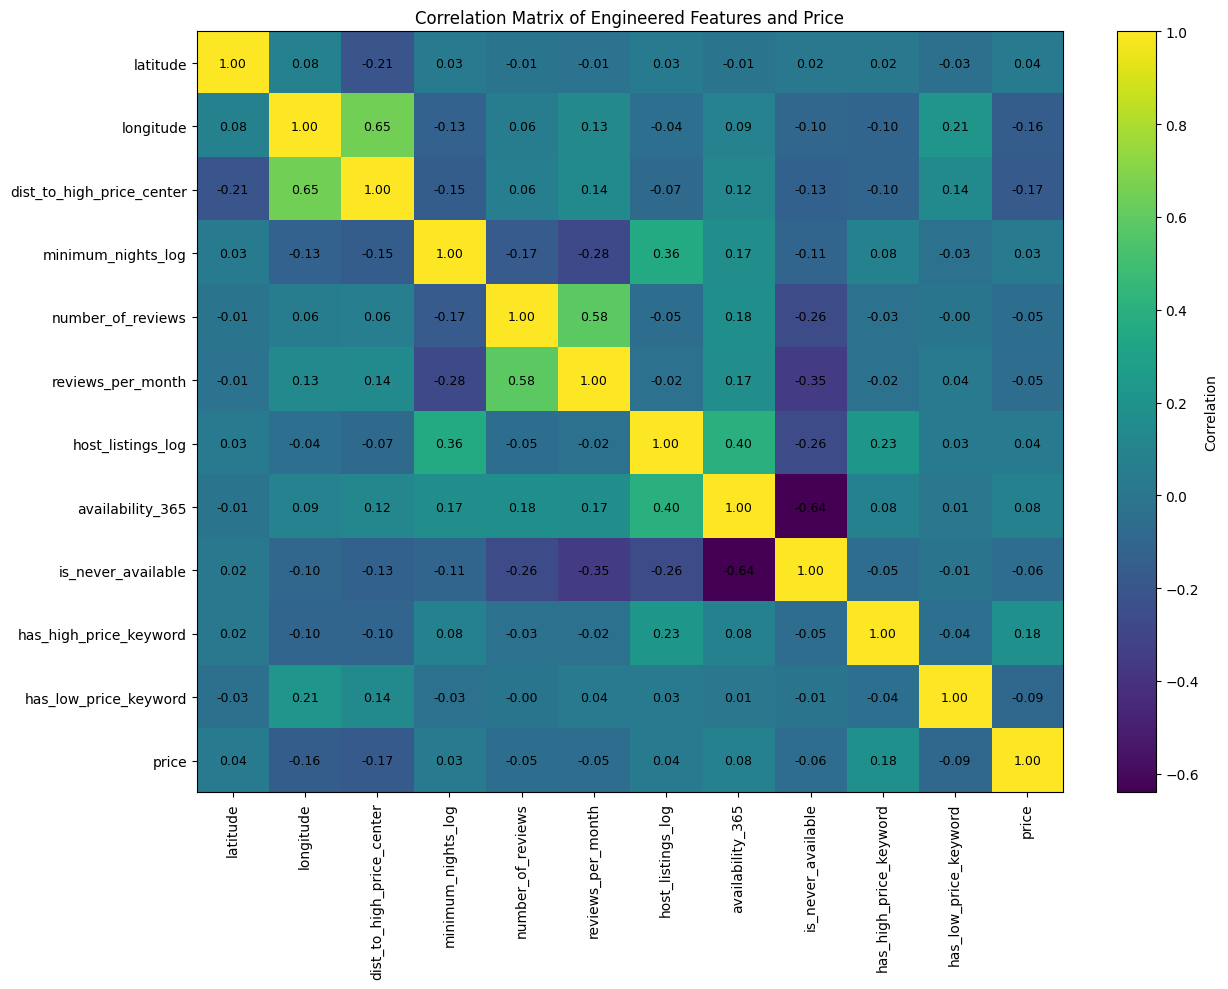

In [15]:
import matplotlib.pyplot as plt

# Create engineered training features for correlation analysis
X_engineered = feature_engineer.fit_transform(
    X_train_raw,
    y_train
)

# Add the keyword flags too (learned on the full training set here,
# just for this exploratory correlation check)
X_keywords = name_keyword_featurizer.transform(X_train_raw)

X_engineered["has_high_price_keyword"] = X_keywords["has_high_price_keyword"]
X_engineered["has_low_price_keyword"] = X_keywords["has_low_price_keyword"]

corr_features = [
    
    "latitude",
    "longitude",
    "dist_to_high_price_center",
    "minimum_nights_log",
    "number_of_reviews",
    "reviews_per_month",
    "host_listings_log",
    "availability_365",
    "is_never_available",
    "has_high_price_keyword",
    "has_low_price_keyword"
]

corr_df = X_engineered[corr_features].copy()

# Add price for correlation comparison
corr_df["price"] = train_df.loc[y_train.index, "price"]

corr = corr_df.corr()

plt.figure(figsize=(13, 10))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=9
        )

plt.title(
    "Correlation Matrix of Engineered Features and Price"
)

plt.tight_layout()
plt.show()

## Preprocessing Summary

The final pipeline combines the selected numerical, spatial, categorical, and keyword-derived features into one reusable preprocessing workflow. The only spatial feature kept is distance from the city-wide high-price centre; the earlier distance-from-neighbourhood-centre feature was dropped.

Skewed numerical variables are transformed with `log1p`, while `room_type`, `neighbourhood`, and `neighbourhood_group` are all one-hot encoded. The target, `price`, is used directly without any transformation.

All target-dependent transformations are learned from training data only. The resulting pipeline can therefore be reused consistently during cross-validation, final testing, and deployment.

### Baseline Regression Models

We first compare three regression approaches with increasing model complexity: **Ridge Regression** as a linear baseline, **Random Forest Regressor** to capture nonlinear relationships, and **HistGradientBoosting Regressor** as a boosting-based model.

All three models use the same preprocessing and feature-engineering pipeline, allowing a fair comparison of their predictive performance. The models are trained directly on `price` in dollars.

Cross-validation is performed only on the training data. **MAE, RMSE, and R²** are calculated directly in dollars, while the untouched test set is reserved for final evaluation after model selection.

In [16]:
from sklearn.base import clone
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor
)
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np
import pandas as pd


# ============================================================
# MODEL DEFINITIONS
# ============================================================

models = {
    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(
        alpha=1.0
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "HistGradientBoosting": HistGradientBoostingRegressor(
        random_state=42
    )
}


# ============================================================
# CROSS-VALIDATION SETTINGS
# ============================================================

N_FOLDS = 5
cv = KFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=42
)


# ============================================================
# STORAGE FOR RESULTS
# ============================================================

cv_results = []
fold_predictions = {}


# ============================================================
# CROSS-VALIDATE EACH MODEL
# ============================================================

for model_name, model in models.items():

    print("\n" + "=" * 80)
    print(model_name)
    print("=" * 80)

    model_fold_results = []

    for fold, (train_idx, valid_idx) in enumerate(
        cv.split(X_train_raw),
        start=1
    ):

        # ----------------------------------------------------
        # Split training data into current CV fold
        # ----------------------------------------------------

        X_fold_train = X_train_raw.iloc[train_idx]
        X_fold_valid = X_train_raw.iloc[valid_idx]

        y_fold_train = y_train.iloc[train_idx]
        y_fold_valid = y_train.iloc[valid_idx]


        # ----------------------------------------------------
        # Build a completely fresh pipeline for this fold
        # ----------------------------------------------------

        fold_pipeline = Pipeline([
            (
                "preprocessing",
                clone(preprocessing_pipeline)
            ),
            (
                "model",
                clone(model)
            )
        ])


        # ----------------------------------------------------
        # Fit on fold training data
        # ----------------------------------------------------

        fold_pipeline.fit(
            X_fold_train,
            y_fold_train
        )


        # ----------------------------------------------------
        # Predict validation fold
        # ----------------------------------------------------

        predictions = fold_pipeline.predict(
            X_fold_valid
        )

        actuals = y_fold_valid

        # Prevent tiny numerical negative predictions.
        predictions = np.maximum(
            predictions,
            0
        )


        # ----------------------------------------------------
        # Calculate validation metrics
        # ----------------------------------------------------

        mae = mean_absolute_error(
            actuals,
            predictions
        )

        rmse = np.sqrt(
            mean_squared_error(
                actuals,
                predictions
            )
        )

        r2 = r2_score(
            actuals,
            predictions
        )


        model_fold_results.append({
            "Model": model_name,
            "Fold": fold,
            "MAE": mae,
            "RMSE": rmse,
            "R²": r2
        })


        # ----------------------------------------------------
        # Top 5 largest validation errors
        # ----------------------------------------------------

        comparison = pd.DataFrame({
            "Actual Price": actuals.to_numpy(),
            "Predicted Price": predictions,
        }, index=X_fold_valid.index)

        comparison["Absolute Error"] = (
            comparison["Actual Price"] -
            comparison["Predicted Price"]
        ).abs()

        comparison["Error"] = (
            comparison["Predicted Price"] -
            comparison["Actual Price"]
        )

        top_5_errors = (
            comparison
            .sort_values(
                "Absolute Error",
                ascending=False
            )
            .head(5)
            .copy()
        )

        print(f"\nFold {fold}")
        print(
            f"MAE:  ${mae:.2f} | "
            f"RMSE: ${rmse:.2f} | "
            f"R²: {r2:.4f}"
        )

        print("\nTop 5 largest validation errors:")

        display(
            top_5_errors[
                [
                    "Actual Price",
                    "Predicted Price",
                    "Absolute Error",
                    "Error"
                ]
            ].round(2)
        )


    # --------------------------------------------------------
    # Store fold results
    # --------------------------------------------------------

    cv_results.extend(
        model_fold_results
    )


# ============================================================
# CV RESULTS — EACH FOLD
# ============================================================

cv_results_df = pd.DataFrame(
    cv_results
)

print("\n" + "=" * 80)
print("CROSS-VALIDATION RESULTS — EACH FOLD")
print("=" * 80)

display(
    cv_results_df.round(4)
)


# ============================================================
# CV RESULTS — MODEL SUMMARY
# ============================================================

cv_summary = (
    cv_results_df
    .groupby("Model")
    .agg(
        MAE_mean=("MAE", "mean"),
        MAE_std=("MAE", "std"),
        RMSE_mean=("RMSE", "mean"),
        RMSE_std=("RMSE", "std"),
        R2_mean=("R²", "mean"),
        R2_std=("R²", "std")
    )
    .sort_values(
        "RMSE_mean"
    )
)

print("\n" + "=" * 80)
print("CROSS-VALIDATION MODEL SUMMARY")
print("=" * 80)

display(
    cv_summary.round(4)
)


Linear Regression

Fold 1
MAE:  $70.58 | RMSE: $193.99 | R²: 0.1621

Top 5 largest validation errors:


,Actual Price,Predicted Price,Absolute Error,Error
37194,6500,158.34,6341.66,-6341.66
3537,6000,272.11,5727.89,-5727.89
15560,6000,359.83,5640.17,-5640.17
28947,4160,360.05,3799.95,-3799.95
42542,3613,282.00,3331.00,-3331.00



Fold 2
MAE:  $67.33 | RMSE: $188.64 | R²: 0.1688

Top 5 largest validation errors:


,Actual Price,Predicted Price,Absolute Error,Error
30268,8500,476.21,8023.79,-8023.79
3774,6500,217.46,6282.54,-6282.54
22353,5000,222.59,4777.41,-4777.41
42736,4100,249.76,3850.24,-3850.24
25901,3900,272.84,3627.16,-3627.16



Fold 3
MAE:  $74.90 | RMSE: $252.91 | R²: 0.1092

Top 5 largest validation errors:


...

,Actual Price,Predicted Price,Absolute Error,Error
6530,9999,138.06,9860.94,-9860.94
40433,9999,485.48,9513.52,-9513.52
44034,6800,1381.04,5418.96,-5418.96
29664,6419,1529.31,4889.69,-4889.69
25825,5000,126.07,4873.93,-4873.93



CROSS-VALIDATION RESULTS — EACH FOLD


,Model,Fold,MAE,RMSE,R²
0,Linear Regression,1,70.5780,193.9881,0.1621
1,Linear Regression,2,67.3291,188.6421,0.1688
2,Linear Regression,3,74.9025,252.9126,0.1092
3,Linear Regression,4,68.9083,183.9144,0.1673
4,Linear Regression,5,73.5427,248.1157,0.1068
5,Ridge Regression,1,70.4127,193.8865,0.1630
6,Ridge Regression,2,67.2995,188.6684,0.1686
7,Ridge Regression,3,74.7643,252.8309,0.1098
8,Ridge Regression,4,68.8095,183.6972,0.1692
9,Ridge Regression,5,73.4380,248.0096,0.1076



CROSS-VALIDATION MODEL SUMMARY


,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
Model,,,,,,
HistGradientBoosting,65.1087,3.0507,206.4537,31.1823,0.1972,0.0225
Ridge Regression,70.9448,3.1199,213.4185,34.0122,0.1436,0.0320
Linear Regression,71.0521,3.1508,213.5146,34.0056,0.1428,0.0319
Random Forest,64.8627,3.0278,213.5877,32.0372,0.1401,0.0379


In [17]:
# ============================================================
# TASK 2 — HYPERPARAMETER TUNING: RANDOM FOREST
# ============================================================

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score

# --------------------------------------------
# Custom scorer: score in DOLLARS.
# The model is trained directly on price, and the metric
# we care about (and report everywhere else in this
# notebook) is dollar MAE.
# --------------------------------------------

def mae_on_price_scale(y_true, y_pred):
    y_pred = np.maximum(y_pred, 0)
    return mean_absolute_error(y_true, y_pred)

price_mae_scorer = make_scorer(mae_on_price_scale, greater_is_better=False)

# --------------------------------------------
# Full pipeline: preprocessing + model together, so the
# target encoder and high-price-centre distance feature
# are refit leak-safely inside every fold the search runs.
# --------------------------------------------

rf_pipeline = Pipeline([
    ("preprocessing", clone(preprocessing_pipeline)),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

# Moderate, hand-picked search space — the handful of RF
# knobs that actually move the needle, not an exhaustive grid.
rf_param_distributions = {
    "model__n_estimators": [200, 300, 400, 500],
    "model__max_depth": [None, 10, 15, 20, 25],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", 0.5, 0.7]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_distributions,
    n_iter=25,              # drop to 15 if this is too slow on your machine
    scoring=price_mae_scorer,
    cv=cv,                   # same KFold(5) used in the baseline comparison
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True
)

rf_search.fit(X_train_raw, y_train)

print("BEST RANDOM FOREST PARAMETERS")
print("-" * 55)
for k, v in rf_search.best_params_.items():
    print(f"{k:25s}: {v}")
print(f"\nBest CV MAE (dollars): ${-rf_search.best_score_:.2f}")

Fitting 5 folds for each of 25 candidates, totalling 125 fits
BEST RANDOM FOREST PARAMETERS
-------------------------------------------------------
model__n_estimators      : 400
model__min_samples_split : 2
model__min_samples_leaf  : 4
model__max_features      : 0.5
model__max_depth         : 25

Best CV MAE (dollars): $62.68


In [18]:
# ============================================================
# TASK 2 — HYPERPARAMETER TUNING: HISTGRADIENTBOOSTING
# ============================================================

hgb_pipeline = Pipeline([
    ("preprocessing", clone(preprocessing_pipeline)),
    ("model", HistGradientBoostingRegressor(random_state=42))
])

hgb_param_distributions = {
    "model__learning_rate": [0.03, 0.05, 0.08, 0.1, 0.15],
    "model__max_iter": [150, 250, 350, 500],
    "model__max_leaf_nodes": [15, 31, 63, 127],
    "model__min_samples_leaf": [10, 20, 30, 50],
    "model__l2_regularization": [0.0, 0.1, 0.5, 1.0]
}

hgb_search = RandomizedSearchCV(
    estimator=hgb_pipeline,
    param_distributions=hgb_param_distributions,
    n_iter=25,
    scoring=price_mae_scorer,
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True
)

hgb_search.fit(X_train_raw, y_train)

print("BEST HISTGRADIENTBOOSTING PARAMETERS")
print("-" * 55)
for k, v in hgb_search.best_params_.items():
    print(f"{k:25s}: {v}")
print(f"\nBest CV MAE (dollars): ${-hgb_search.best_score_:.2f}")

Fitting 5 folds for each of 25 candidates, totalling 125 fits


c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


BEST HISTGRADIENTBOOSTING PARAMETERS
-------------------------------------------------------
model__min_samples_leaf  : 20
model__max_leaf_nodes    : 127
model__max_iter          : 150
model__learning_rate     : 0.03
model__l2_regularization : 0.1

Best CV MAE (dollars): $64.85


In [19]:
# ============================================================
# TASK 2 — TUNED vs BASELINE COMPARISON
# ============================================================

tuned_summary = pd.DataFrame([
    {"Model": "Random Forest (tuned)", "CV MAE ($)": -rf_search.best_score_},
    {"Model": "HistGradientBoosting (tuned)", "CV MAE ($)": -hgb_search.best_score_}
])

baseline_summary = (
    cv_summary[["MAE_mean"]]
    .rename(columns={"MAE_mean": "CV MAE ($)"})
    .reset_index()
)
baseline_summary["Model"] = baseline_summary["Model"] + " (baseline)"

comparison_df = (
    pd.concat([baseline_summary, tuned_summary], ignore_index=True)
    .sort_values("CV MAE ($)")
)

print("BASELINE vs TUNED — CV MAE COMPARISON")
print("-" * 55)
display(comparison_df.round(2))

BASELINE vs TUNED — CV MAE COMPARISON
-------------------------------------------------------


,Model,CV MAE ($)
4,Random Forest (tuned),62.68
5,HistGradientBoosting (tuned),64.85
3,Random Forest (baseline),64.86
0,HistGradientBoosting (baseline),65.11
1,Ridge Regression (baseline),70.94
2,Linear Regression (baseline),71.05


In [20]:
# ============================================================
# TASK 2 — Final evaluation on the untouched test set
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Separate test features and target
X_test = test_df.drop(columns=["price"])
y_test = test_df["price"]

# Get the best pipelines found by RandomizedSearchCV
best_rf_pipeline = rf_search.best_estimator_
best_hgb_pipeline = hgb_search.best_estimator_


def evaluate_on_test(model, X_test, y_test, model_name):
    # Model predicts price directly
    y_pred = model.predict(X_test)

    # Prevent any tiny negative numerical predictions
    y_pred = np.maximum(y_pred, 0)

    # Metrics in dollars
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"\n{model_name} — Test Set")
    print("-" * 40)
    print(f"MAE  : ${mae:.2f}")
    print(f"RMSE : ${rmse:.2f}")
    print(f"R²   : {r2:.4f}")

    return {
        "Model": model_name,
        "Test MAE": mae,
        "Test RMSE": rmse,
        "Test R²": r2
    }


# Evaluate both tuned models
rf_test_results = evaluate_on_test(
    best_rf_pipeline,
    X_test,
    y_test,
    "Tuned Random Forest"
)

hgb_test_results = evaluate_on_test(
    best_hgb_pipeline,
    X_test,
    y_test,
    "Tuned HistGradientBoosting"
)


# Comparison table
test_results = pd.DataFrame([
    rf_test_results,
    hgb_test_results
])

print("\nFinal Test-Set Comparison")
print("=" * 60)
display(test_results)


Tuned Random Forest — Test Set
----------------------------------------
MAE  : $56.50
RMSE : $183.77
R²   : 0.2366

Tuned HistGradientBoosting — Test Set
----------------------------------------
MAE  : $59.77
RMSE : $184.94
R²   : 0.2268

Final Test-Set Comparison


,Model,Test MAE,Test RMSE,Test R²
0,Tuned Random Forest,56.502766,183.766170,0.236633
1,Tuned HistGradientBoosting,59.770137,184.942908,0.226825


In [21]:
# ============================================================
# TASK 2 — Correct Train vs Test Overfitting Check
# ============================================================

# Models are trained directly on price, so we evaluate
# directly in dollars — no transform needed.

def evaluate_on_original_price_scale(model, X, y_actual, model_name):
    # Model prediction is in dollars
    y_pred = model.predict(X)

    # Avoid tiny negative numerical values
    y_pred = np.maximum(y_pred, 0)

    mae = mean_absolute_error(y_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    r2 = r2_score(y_actual, y_pred)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    }


# Training performance
rf_train = evaluate_on_original_price_scale(
    best_rf_pipeline,
    X_train_raw,
    train_df["price"],
    "Tuned Random Forest"
)

hgb_train = evaluate_on_original_price_scale(
    best_hgb_pipeline,
    X_train_raw,
    train_df["price"],
    "Tuned HistGradientBoosting"
)


# Test performance
rf_test = evaluate_on_original_price_scale(
    best_rf_pipeline,
    X_test,
    test_df["price"],
    "Tuned Random Forest"
)

hgb_test = evaluate_on_original_price_scale(
    best_hgb_pipeline,
    X_test,
    test_df["price"],
    "Tuned HistGradientBoosting"
)


# Create comparison table
overfit_results = pd.DataFrame([
    {
        "Model": "Tuned Random Forest",
        "Train MAE": rf_train["MAE"],
        "Train RMSE": rf_train["RMSE"],
        "Train R²": rf_train["R²"],
        "Test MAE": rf_test["MAE"],
        "Test RMSE": rf_test["RMSE"],
        "Test R²": rf_test["R²"]
    },
    {
        "Model": "Tuned HistGradientBoosting",
        "Train MAE": hgb_train["MAE"],
        "Train RMSE": hgb_train["RMSE"],
        "Train R²": hgb_train["R²"],
        "Test MAE": hgb_test["MAE"],
        "Test RMSE": hgb_test["RMSE"],
        "Test R²": hgb_test["R²"]
    }
])

display(overfit_results)

,Model,Train MAE,Train RMSE,Train R²,Test MAE,Test RMSE,Test R²
0,Tuned Random Forest,48.043360,172.582262,0.446648,56.502766,183.766170,0.236633
1,Tuned HistGradientBoosting,57.633997,175.611239,0.427054,59.770137,184.942908,0.226825


In [24]:
# ============================================================
# FEATURE IMPORTANCE — TUNED MODELS
# ============================================================
#
# Random Forest exposes native impurity-based importances.
# HistGradientBoosting does not, so permutation importance
# (on the held-out test set) is used for it instead. Both are
# computed in the *transformed* feature space so the real
# (post-preprocessing) feature names line up correctly.

from sklearn.inspection import permutation_importance


def get_real_names(pipeline):

    pre = pipeline.named_steps["preprocessing"]
    ct = pre.named_steps["preprocessing"]

    names = []

    for transformer_name, transformer, columns in ct.transformers_:

        if transformer == "drop":
            continue

        if isinstance(columns, (list, tuple, np.ndarray, pd.Index)):
            cols = list(columns)
        else:
            cols = list(X_train_raw.columns[columns])

        if isinstance(transformer, Pipeline):

            encoder = None
            for _, step in transformer.steps:
                if hasattr(step, "categories_"):
                    encoder = step
                    break

            if encoder is not None:
                for col, categories in zip(cols, encoder.categories_):
                    for category in categories:
                        names.append(f"{col} = {category}")
                continue

            try:
                names.extend(transformer.get_feature_names_out(cols))
                continue
            except Exception:
                pass

        try:
            names.extend(transformer.get_feature_names_out(cols))
        except Exception:
            names.extend(cols)

    n_features = pre.transform(X_train_raw.iloc[:1]).shape[1]

    if len(names) != n_features:
        try:
            names = list(pre.get_feature_names_out())
        except Exception:
            pass

    if len(names) != n_features:
        names = [f"Feature_{i}" for i in range(n_features)]

    return names


importance_results = {}

# --- Random Forest: native impurity-based importances ---
rf_importances = best_rf_pipeline.named_steps["model"].feature_importances_
importance_results["Tuned Random Forest"] = pd.DataFrame({
    "Magnitude": rf_importances,
    "Direction": ["Positive"] * len(rf_importances)
})

# --- HistGradientBoosting: permutation importance on transformed features ---
X_test_transformed_hgb = best_hgb_pipeline.named_steps["preprocessing"].transform(X_test)

hgb_perm = permutation_importance(
    best_hgb_pipeline.named_steps["model"],
    X_test_transformed_hgb,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importance_results["Tuned HistGradientBoosting"] = pd.DataFrame({
    "Magnitude": np.abs(hgb_perm.importances_mean),
    "Direction": np.where(hgb_perm.importances_mean >= 0, "Positive", "Negative")
})

# ============================================================
# SHOW TOP 10 POSITIVE / NEGATIVE PER MODEL
# ============================================================

for model_name, importance_df in importance_results.items():

    pipe = best_rf_pipeline if "Random Forest" in model_name else best_hgb_pipeline

    names = get_real_names(pipe)

    df = importance_df.copy()
    df["Feature"] = names

    pos = df[df["Direction"] == "Positive"].nlargest(10, "Magnitude")
    neg = df[df["Direction"] == "Negative"].nlargest(10, "Magnitude")

    print(f"\n{model_name}")

    print(
        "↑ "
        + " | ".join(f"{r.Feature} ({r.Magnitude:.3f})" for r in pos.itertuples())
    )

    if len(neg):
        print(
            "↓ "
            + " | ".join(f"{r.Feature} ({r.Magnitude:.3f})" for r in neg.itertuples())
        )



Tuned Random Forest
↑ longitude (0.147) | dist_to_high_price_center (0.130) | latitude (0.119) | availability_365 (0.105) | room_type = Entire home/apt (0.095) | minimum_nights_log (0.070) | reviews_per_month (0.057) | host_listings_log (0.057) | has_high_price_keyword (0.046) | number_of_reviews (0.042)

Tuned HistGradientBoosting
↑ room_type = Entire home/apt (0.219) | minimum_nights_log (0.149) | availability_365 (0.132) | host_listings_log (0.063) | dist_to_high_price_center (0.048) | longitude (0.044) | reviews_per_month (0.027) | number_of_reviews (0.026) | latitude (0.025) | has_high_price_keyword (0.024)
↓ neighbourhood = Chelsea (0.001) | neighbourhood = Upper East Side (0.000) | neighbourhood = Nolita (0.000) | neighbourhood = Upper West Side (0.000) | neighbourhood = Harlem (0.000) | neighbourhood = East Village (0.000) | neighbourhood = Cypress Hills (0.000) | has_low_price_keyword (0.000) | neighbourhood = Crown Heights (0.000) | neighbourhood = Little Italy (0.000)


## Export Trained Pipeline for the Streamlit App

The tuned HistGradientBoosting pipeline (preprocessing + model, fit on the full training set by `RandomizedSearchCV`'s `refit=True`) is saved as `airbnb_price_pipeline.joblib`. Copy this file next to `model_pipeline.py` and `app.py` so `predict_price()` can load it.

In [25]:
# ============================================================
# EXPORT TUNED PIPELINE FOR DEPLOYMENT (Streamlit app)
# ============================================================

import joblib

PIPELINE_EXPORT_PATH = "airbnb_price_pipeline.joblib"

joblib.dump(best_hgb_pipeline, PIPELINE_EXPORT_PATH)

print(f"Saved tuned pipeline to: {PIPELINE_EXPORT_PATH}")
print("Copy this file next to model_pipeline.py and app.py.")


Saved tuned pipeline to: airbnb_price_pipeline.joblib
Copy this file next to model_pipeline.py and app.py.
